In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/adhee/INFOSYS/Milestones/Milestone1/data/Clean-Data")
df

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,0,28,0,28.0
1,2023-01-01 01:00:00,119,0,84,0,203.0
2,2023-01-01 02:00:00,135,0,47,0,182.0
3,2023-01-01 03:00:00,171,0,21,0,192.0
4,2023-01-01 04:00:00,0,0,88,0,88.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,146,2221,23,0,2390.0
4317,2023-06-29 21:00:00,72,1887,31,0,1990.0
4318,2023-06-29 22:00:00,156,1982,0,0,2138.0
4319,2023-06-29 23:00:00,149,1143,43,0,1335.0


In [8]:
target_col = 'total_power'

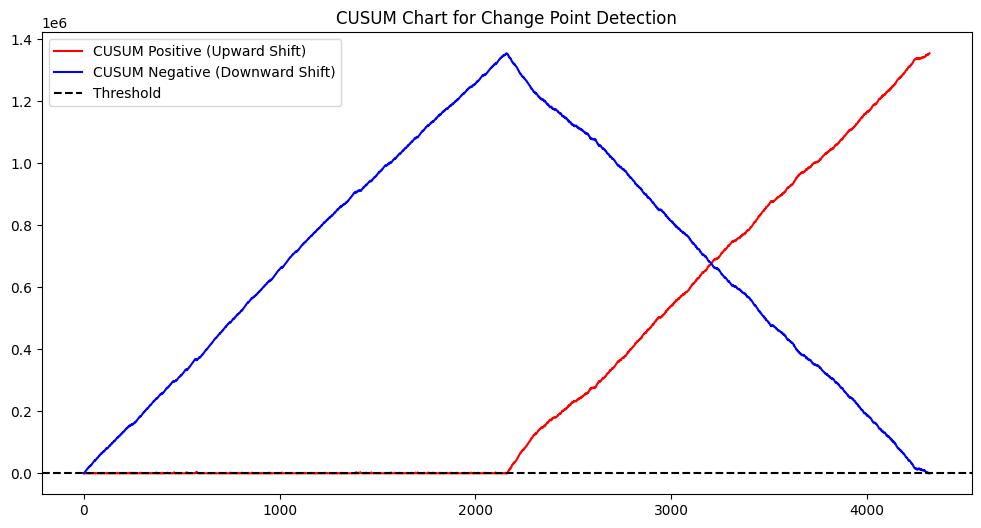

In [9]:
def detect_cusum(x, threshold=5, drift=0.5):
    S_pos = np.zeros(len(x))
    S_neg = np.zeros(len(x))
    mu = np.mean(x)
    
    for i in range(1, len(x)):
        S_pos[i] = max(0, S_pos[i-1] + (x[i] - mu) - drift)
        S_neg[i] = max(0, S_neg[i-1] - (x[i] - mu) - drift)
    
    return S_pos, S_neg

S_pos, S_neg = detect_cusum(df[target_col].values)

plt.figure(figsize=(12, 6))
plt.plot(df.index, S_pos, label='CUSUM Positive (Upward Shift)', color='red')
plt.plot(df.index, S_neg, label='CUSUM Negative (Downward Shift)', color='blue')
plt.axhline(50, color='black', linestyle='--', label='Threshold')
plt.title('CUSUM Chart for Change Point Detection')
plt.legend()
plt.show()

C:\Users\adhee\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_continuous_distns.py:6921: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\adhee\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\adhee\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_distn_infrastructure.py:2055: RuntimeWarning: overflow encountered in divide
  place(output, cond, self._pdf(*goodargs) / scale)


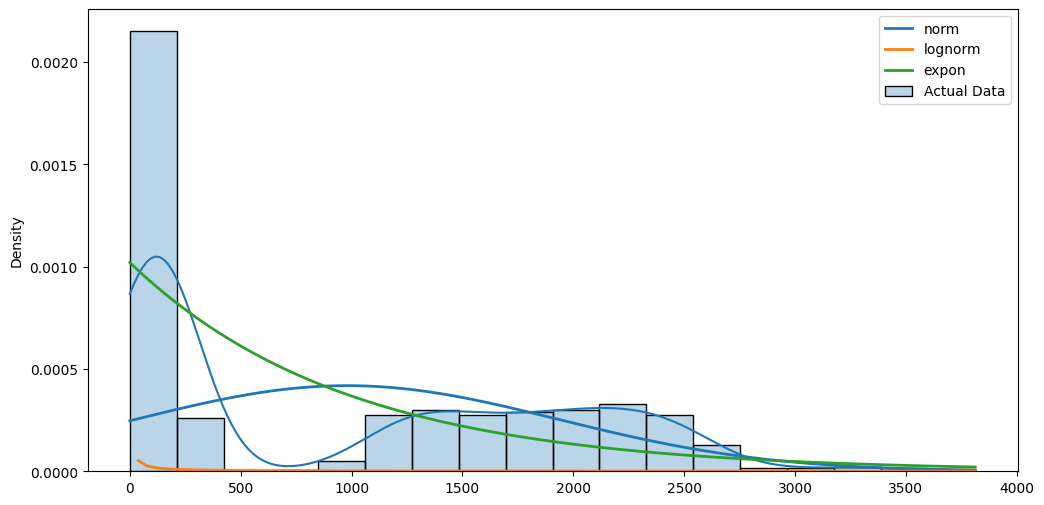

In [11]:
from scipy import stats
data = df[target_col].dropna().values
distributions = [stats.norm, stats.lognorm, stats.expon]

plt.figure(figsize = (12,6))
sns.histplot(data, kde=True, stat="density",alpha=0.3,label = "Actual Data")

x = np.linspace(min(data),max(data),100)
for dist in distributions:
    params = dist.fit(data)
    pdf = dist.pdf(x,*params)
    plt.plot(x,pdf,label=dist.name, linewidth=2)

plt.legend()
plt.show()

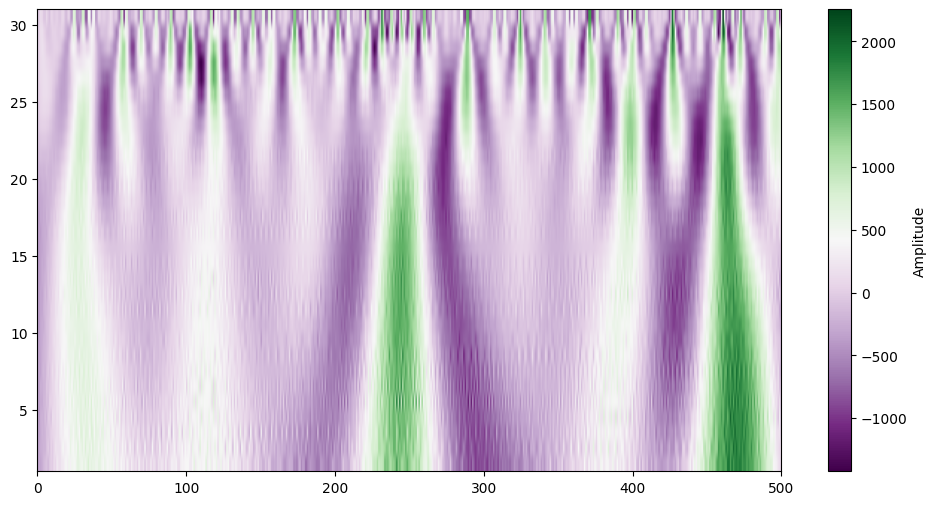

In [19]:
import pywt
from scipy import signal
width = np.arange(1,31)
data = df[target_col].values[:500]
scales = np.arange(1, 31)
coefficients, frequencies = pywt.cwt(data, scales, 'mexh')

plt.figure(figsize=(12,6))
plt.imshow(coefficients,
           extent=[0, 500, 1, 31],
           cmap="PRGn",
           aspect='auto',
           vmax=abs(coefficients).max())
plt.colorbar(label='Amplitude')
plt.show()